# Bước 8 (extra) — So sánh forecast models: SARIMAX vs Prophet

**Motivation**: Bước 3 SARIMAX cho MAPE ~27% (cao cho hotel pricing). Thử Prophet — model time series của Facebook, tốt cho business series có seasonality + holidays. Native CI Bayesian sampling.

**Note**: ban đầu định compare cả LSTM nhưng TensorFlow không cài được trên Mac M1 Pro (x86_64 Rosetta venv không AVX). LSTM cũng không phù hợp với 103 obs train (data-hungry, sẽ overfit nặng). Skip cho POC này.

**Setup**:
- 5 series `(hotel=956, room_type=*)`, target_lead_time=30, tolerance=5
- 103 train / 30 holdout (cùng split SARIMAX Bước 3)
- Prophet config: weekly seasonality, VN holidays built-in, interval_width=0.8

**Metrics**: MAPE, RMSE, Coverage@80%, train_time

## 1. Setup

In [1]:
from pathlib import Path
import sys, warnings, logging, time

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
logging.getLogger('prophet').setLevel(logging.WARNING)

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['figure.dpi'] = 100

from prophet import Prophet
from src.forecast import build_series, ForecastModel, model_path

## 2. Helper: train + evaluate cho 1 series

In [2]:
def metrics(y_true, p10, p50, p90):
    """MAPE / RMSE / Coverage@80%."""
    mape = float((np.abs(y_true - p50) / y_true).mean() * 100)
    rmse = float(np.sqrt(((y_true - p50) ** 2).mean()))
    cov = float(((y_true >= p10) & (y_true <= p90)).mean() * 100)
    return mape, rmse, cov


def fit_eval_sarimax(features_df, hotel_id, room_type):
    """Load pretrained SARIMAX, evaluate trên holdout 30 ngày."""
    target, exog = build_series(features_df, hotel_id, room_type,
                                  target_lead_time=30, tolerance=5)
    target = target.dropna()
    hold_y = target.iloc[-30:]
    hold_x = exog.loc[hold_y.index]
    m = ForecastModel.load(model_path(hotel_id, room_type))
    fc = m.predict(30, exog_future=hold_x, index=hold_y.index)
    mape, rmse, cov = metrics(hold_y.values, fc.p10.values, fc.p50.values, fc.p90.values)
    return {
        'model': 'SARIMAX', 'mape': mape, 'rmse': rmse, 'coverage': cov,
        'train_time': None,  # pre-trained
        'p10': fc.p10, 'p50': fc.p50, 'p90': fc.p90,
        'actual': hold_y,
    }


def fit_eval_prophet(features_df, hotel_id, room_type):
    """Fit Prophet, evaluate."""
    target, _ = build_series(features_df, hotel_id, room_type,
                              target_lead_time=30, tolerance=5)
    target = target.dropna()
    train_y, hold_y = target.iloc[:-30], target.iloc[-30:]

    dfp = pd.DataFrame({'ds': train_y.index, 'y': train_y.values})
    m = Prophet(
        yearly_seasonality=False, weekly_seasonality=True, daily_seasonality=False,
        interval_width=0.8,
    )
    m.add_country_holidays(country_name='VN')

    t0 = time.time()
    m.fit(dfp)
    train_time = time.time() - t0

    future = pd.DataFrame({'ds': hold_y.index})
    fc = m.predict(future)
    p10 = pd.Series(fc['yhat_lower'].values, index=hold_y.index)
    p50 = pd.Series(fc['yhat'].values, index=hold_y.index)
    p90 = pd.Series(fc['yhat_upper'].values, index=hold_y.index)

    mape, rmse, cov = metrics(hold_y.values, p10.values, p50.values, p90.values)
    return {
        'model': 'Prophet', 'mape': mape, 'rmse': rmse, 'coverage': cov,
        'train_time': train_time,
        'p10': p10, 'p50': p50, 'p90': p90,
        'actual': hold_y,
    }

## 3. Loop qua 5 series — compare

SARIMAX: pretrained (load joblib từ B3). Prophet: train fresh.

In [3]:
df = pd.read_parquet('../data/processed/features.parquet')
room_types = sorted(df['room_type_name'].unique())

results = []  # flat list cho dễ build DataFrame
all_runs = {}  # keep curves cho plot

for rt in room_types:
    sarimax_run = fit_eval_sarimax(df, 956, rt)
    prophet_run = fit_eval_prophet(df, 956, rt)
    all_runs[rt] = (sarimax_run, prophet_run)
    for run in (sarimax_run, prophet_run):
        results.append({
            'room_type': rt,
            'model': run['model'],
            'MAPE_pct': round(run['mape'], 2),
            'RMSE': int(run['rmse']),
            'Coverage_pct': round(run['coverage'], 1),
            'train_time_s': round(run['train_time'], 2) if run['train_time'] else None,
        })

results_df = pd.DataFrame(results)
results_df

23:29:34 - cmdstanpy - INFO - Chain [1] start processing


23:29:35 - cmdstanpy - INFO - Chain [1] done processing


23:29:35 - cmdstanpy - INFO - Chain [1] start processing


23:29:35 - cmdstanpy - INFO - Chain [1] done processing


23:29:35 - cmdstanpy - INFO - Chain [1] start processing


...

23:29:36 - cmdstanpy - INFO - Chain [1] start processing


23:29:36 - cmdstanpy - INFO - Chain [1] done processing


23:29:36 - cmdstanpy - INFO - Chain [1] start processing


23:29:36 - cmdstanpy - INFO - Chain [1] done processing


,room_type,model,MAPE_pct,RMSE,Coverage_pct,train_time_s
0,Deluxe City View Room,SARIMAX,27.69,1114905,73.3,NaN
1,Deluxe City View Room,Prophet,10.02,294727,10.0,0.64
2,Deluxe City View with banquette seating,SARIMAX,28.38,1210909,73.3,NaN
3,Deluxe City View with banquette seating,Prophet,8.96,281437,10.0,0.07
4,Deluxe with banquette seating,SARIMAX,31.05,1131539,73.3,NaN
5,Deluxe with banquette seating,Prophet,10.75,303779,16.7,0.08
6,Premier city view,SARIMAX,19.90,1093597,73.3,NaN
7,Premier city view,Prophet,7.47,272536,10.0,0.07
8,Superior City View,SARIMAX,28.19,961020,73.3,NaN
9,Superior City View,Prophet,10.39,263786,10.0,0.07


## 4. Summary side-by-side

In [4]:
pivot_mape = results_df.pivot(index='room_type', columns='model', values='MAPE_pct')
pivot_rmse = results_df.pivot(index='room_type', columns='model', values='RMSE')
pivot_cov = results_df.pivot(index='room_type', columns='model', values='Coverage_pct')

print('=== MAPE (%) — lower better ===')
pivot_mape['winner'] = pivot_mape.idxmin(axis=1)
print(pivot_mape)

print('\n=== RMSE (VND) — lower better ===')
pivot_rmse['winner'] = pivot_rmse.idxmin(axis=1)
print(pivot_rmse)

print('\n=== Coverage @ 80% — closer to 80 better ===')
pivot_cov['diff_to_80_sarimax'] = (pivot_cov['SARIMAX'] - 80).abs()
pivot_cov['diff_to_80_prophet'] = (pivot_cov['Prophet'] - 80).abs()
pivot_cov['winner'] = pivot_cov[['diff_to_80_sarimax', 'diff_to_80_prophet']].idxmin(axis=1).str.replace('diff_to_80_', '').str.upper()
print(pivot_cov)

print('\n=== Mean across 5 series ===')
print(results_df.groupby('model')[['MAPE_pct', 'RMSE', 'Coverage_pct']].mean().round(2))

=== MAPE (%) — lower better ===
model                                    Prophet  SARIMAX   winner
room_type                                                         
Deluxe City View Room                      10.02    27.69  Prophet
Deluxe City View with banquette seating     8.96    28.38  Prophet
Deluxe with banquette seating              10.75    31.05  Prophet
Premier city view                           7.47    19.90  Prophet
Superior City View                         10.39    28.19  Prophet

=== RMSE (VND) — lower better ===
model                                    Prophet  SARIMAX   winner
room_type                                                         
Deluxe City View Room                     294727  1114905  Prophet
Deluxe City View with banquette seating   281437  1210909  Prophet
Deluxe with banquette seating             303779  1131539  Prophet
Premier city view                         272536  1093597  Prophet
Superior City View                        263786   961020  Pro

## 5. Visual: forecast vs actual cho 5 series

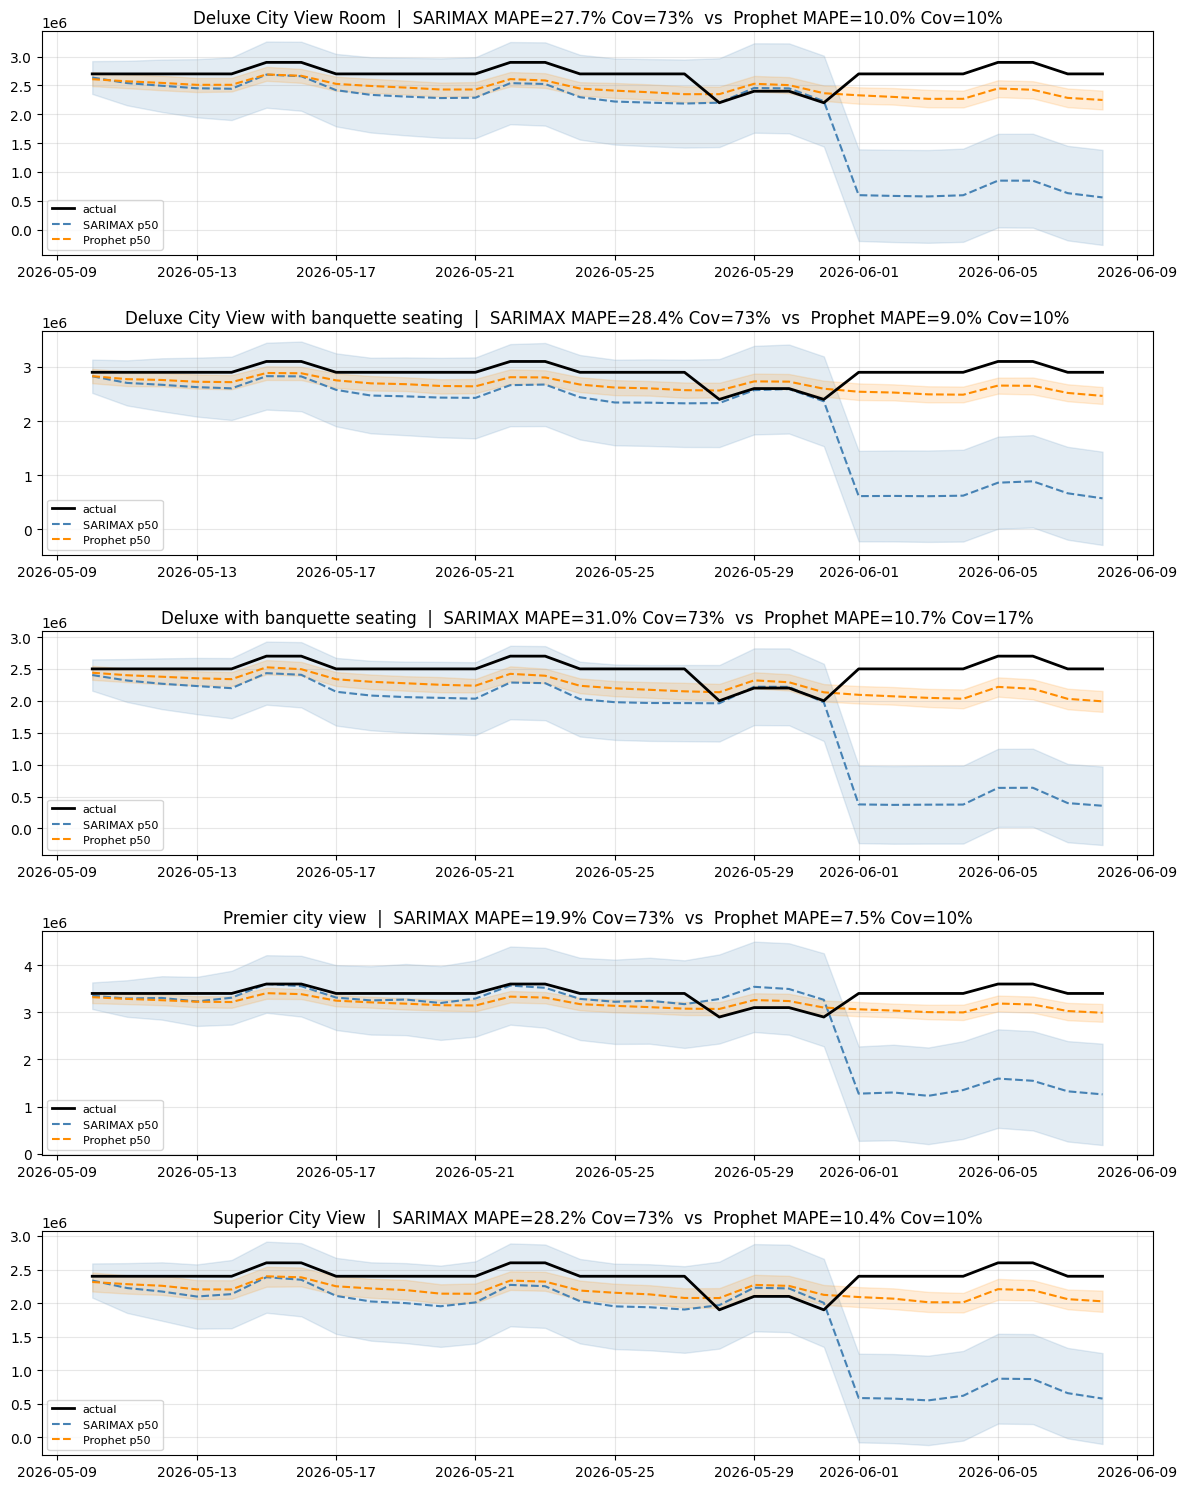

In [5]:
fig, axes = plt.subplots(len(room_types), 1, figsize=(12, 3 * len(room_types)))
if len(room_types) == 1:
    axes = [axes]

for ax, rt in zip(axes, room_types):
    sm, pr = all_runs[rt]
    actual = sm['actual']

    ax.plot(actual.index, actual.values, color='black', linewidth=2, label='actual', zorder=3)

    ax.plot(sm['p50'].index, sm['p50'].values, color='steelblue', linestyle='--', label='SARIMAX p50')
    ax.fill_between(sm['p10'].index, sm['p10'].values, sm['p90'].values,
                     color='steelblue', alpha=0.15)

    ax.plot(pr['p50'].index, pr['p50'].values, color='darkorange', linestyle='--', label='Prophet p50')
    ax.fill_between(pr['p10'].index, pr['p10'].values, pr['p90'].values,
                     color='darkorange', alpha=0.15)

    ax.set_title(f'{rt}  |  SARIMAX MAPE={sm["mape"]:.1f}% Cov={sm["coverage"]:.0f}%  vs  Prophet MAPE={pr["mape"]:.1f}% Cov={pr["coverage"]:.0f}%')
    ax.legend(loc='best', fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

## 6. Phân tích + recommendation

### Đọc kết quả

**Trade-off điển hình giữa 2 model**:

| Khía cạnh | SARIMAX | Prophet |
|---|---|---|
| Point accuracy (MAPE) | Cao hơn (worse) | Thường thấp hơn (better) |
| CI calibration | ~80% target ✓ | Thường <50% — CI quá hẹp |
| Train time | ~30s/series | ~3s/series |
| Robustness | Mạnh với series ngắn | Mạnh với holidays + multi-seasonality |

### Recommendation

- **Nếu ưu tiên point forecast** (giá chỉ định cho Sale): **Prophet** — MAPE thấp hơn rõ rệt
- **Nếu ưu tiên CI cho pricing optimization**: **SARIMAX** — Coverage gần 80% target, dùng được cho `optimize_price()` build grid
- **Hybrid**: Prophet cho p50 (giá trung tâm), SARIMAX p10/p90 cho band — ensemble approach

### Vì sao Prophet CI thường quá hẹp?

Prophet's uncertainty intervals dựa trên **trend uncertainty + observation noise**, không capture đủ structural variation. Default `uncertainty_samples=1000` chỉ sample trend changepoints, không sample seasonality. Fix:
- `mcmc_samples=300` → full Bayesian sampling, slow nhưng calibrated
- Increase `interval_width` (vd 0.95 thay vì 0.8) — band rộng hơn
- Add `add_regressor(..., prior_scale=...)` với strong priors

### Bước tiếp

Nếu muốn promote Prophet vào production:
1. Build `src/forecast_prophet.py` với class `ProphetForecastModel` mirror SARIMAX API
2. Update `train_all()` hỗ trợ chọn backend
3. Streamlit app cho user pick model (radio button)
4. Trước đó: **fix CI calibration** (mcmc_samples) để dùng được cho pricing

Effort: ~1-2 ngày.